In [ ]:
!pip install tqdm boto3 requests regex sentencepiece sacremoses --quiet
!pip install transformers --quiet

In [ ]:
from tqdm.auto import tqdm
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import transformers
from transformers import BertModel, BertTokenizer, get_scheduler, set_seed, AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
# CONFIGURATION CLASS
@dataclass
class Config:
    data_path: str = "/content/drive/MyDrive/Dataset/Sentiment/Res_ABSA/Res_ABSA/Train.txt"
    test_path: str = "/content/drive/MyDrive/Dataset/Sentiment/Res_ABSA/Res_ABSA/Dev.txt"
    output_path: str = "./test.txt"
    batch_size: int = 16
    val_size: int = 500
    train_size: int = 0
    pin_memory: bool = True
    num_workers: int = 2
    seed: int = 42
    lr: float = 5e-5

In [ ]:
config = Config()

In [ ]:
set_seed(config.seed)

In [ ]:
def readData(path):
    with open(path, 'r', encoding='utf-8') as file:
      content = file.read()
      lines = content.split('\n\n')
      data = [line.split('\n') for line in lines]
      df = pd.DataFrame(data, columns=['id', 'reviews', 'label'])
      df = df.drop(['id', 'label'], axis=1)
      def process_data(data):
          rows = []
          for entry in data:
              # Tách phần review và các cặp aspect-sentiment
              review, aspects = entry.split("\n", 1)
              # Tìm tất cả các cặp {aspect, sentiment}
              matches = re.findall(r"\{(.*?),(.*?)\}", aspects)

              # Tạo một hàng cho bảng
              row = {'review': review.strip()}
              for i, (aspect, sentiment) in enumerate(matches, start=1):
                  row[f'aspect{i}'] = aspect.strip()
                  row[f'sentiment{i}'] = sentiment.strip()

              rows.append(row)

          return rows

      # Xử lý dữ liệu
      processed_data = process_data(lines)
      dataset = pd.DataFrame(processed_data)
      dataset = dataset.drop(['review'], axis=1)
      dataset = pd.concat([df, dataset], axis=1)
      dataset = dataset.where(pd.notna(dataset), None)
    return dataset

def GenerateAspectCategoriesDict(df):
    aspectCategories = np.array(df['aspect1'])
    aspectCategories = np.concatenate((aspectCategories, np.array(df['aspect2'])))
    aspectCategories = np.concatenate((aspectCategories, np.array(df['aspect3'])))
    aspectCategories = np.concatenate((aspectCategories, np.array(df['aspect4'])))
    aspectCategories = np.concatenate((aspectCategories, np.array(df['aspect5'])))
    aspectCategories = aspectCategories[aspectCategories != None]

    aspectCategories = aspectCategories.astype(str)
    aspectCategories = np.unique(aspectCategories)

    aspectCategoriesDictIdxToCat = dict(enumerate(aspectCategories))
    aspectCategoriesDictCatToIdx = {}
    for i, j in enumerate(aspectCategories):
        aspectCategoriesDictCatToIdx[j] = i

    return aspectCategoriesDictCatToIdx, aspectCategoriesDictIdxToCat

def PolarityDict():
    polarityDictPolToIdx = {}
    polarityDictIdxToPol = {}
    polarity = ["positive", "neutral", "negative"]
    for i, j in enumerate(polarity):
        polarityDictPolToIdx[j] = i
        polarityDictIdxToPol[i] = j
    return polarityDictPolToIdx, polarityDictIdxToPol

def GenerateAspectPolarityVector(df):
    data = np.array(df)
    aspectDictCatToIdx, aspectDictIdxToCat = GenerateAspectCategoriesDict(df)
    print(aspectDictCatToIdx)
    polarityDictCatToIdx, polarityDictIdxToCat = PolarityDict()

    categoryVec = []
    for i in range(len(df)):
        vec = [0 for k in range(36)]
        for j in range(1, 10, 2):
            if data[i][j] == None:
                break
            temp1 = aspectDictCatToIdx[data[i][j]]
            temp2 = polarityDictCatToIdx[data[i][j+1]]
            vec[(temp1*3)+temp2] = 1
        categoryVec.append(vec)

    return categoryVec

In [ ]:
df = pd.DataFrame(readData(config.data_path))
df["Aspect"] = GenerateAspectPolarityVector(df)


{'AMBIENCE#GENERAL': 0, 'DRINKS#PRICES': 1, 'DRINKS#QUALITY': 2, 'DRINKS#STYLE&OPTIONS': 3, 'FOOD#PRICES': 4, 'FOOD#QUALITY': 5, 'FOOD#STYLE&OPTIONS': 6, 'LOCATION#GENERAL': 7, 'RESTAURANT#GENERAL': 8, 'RESTAURANT#MISCELLANEOUS': 9, 'RESTAURANT#PRICES': 10, 'SERVICE#GENERAL': 11}


In [ ]:
df.head()

,reviews,aspect1,sentiment1,aspect2,sentiment2,aspect3,sentiment3,aspect4,sentiment4,aspect5,sentiment5,Aspect
0,Giá 53k size vừa.,DRINKS#PRICES,neutral,DRINKS#STYLE&OPTIONS,neutral,None,None,None,None,None,None,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
1,Nhưng nói chung cũng hơi đắt.,RESTAURANT#PRICES,negative,None,None,None,None,None,None,None,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Mình ăn rất hôi mùi dầu.,FOOD#QUALITY,negative,None,None,None,None,None,None,None,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Mình ăn chưa baoh thấy mùi hôi hải sản.,FOOD#QUALITY,positive,None,None,None,None,None,None,None,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,3 dĩa vs 2 lon Revive mà có 190k thui(.,RESTAURANT#PRICES,positive,None,None,None,None,None,None,None,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
aspect_conversion_dict = {'RESTAURANT#GENERAL': 0, 'RESTAURANT#PRICES': 1, 'RESTAURANT#MISCELLANEOUS': 2, 'FOOD#QUALITY': 3,
    'FOOD#PRICES': 4, 'FOOD#STYLE&OPTIONS': 5, 'DRINKS#QUALITY': 6, 'DRINKS#PRICES': 7,
    'DRINKS#STYLE&OPTIONS': 8, 'LOCATION#GENERAL': 9, 'AMBIENCE#GENERAL': 10, 'SERVICE#GENERAL': 11}
sentiment_conversion_dict = {'positive': 2, 'neutral': 1, 'negative': 0}

df['aspect1'] = df['aspect1'].apply(lambda x: aspect_conversion_dict[x])
df['sentiment1'] = df['sentiment1'].apply(lambda x: sentiment_conversion_dict[x])

df['aspect2'] = df['aspect2'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
df['sentiment2'] = df['sentiment2'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

df['aspect3'] = df['aspect3'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
df['sentiment3'] = df['sentiment3'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

df['aspect4'] = df['aspect4'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
df['sentiment4'] = df['sentiment4'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

df['aspect5'] = df['aspect5'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
df['sentiment5'] = df['sentiment5'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)


In [ ]:
a1 = df['aspect1']
s1 = df['sentiment1']
a1 += 1
s1 += 1
df['labels1'] = a1*s1 - 1

a2 = df['aspect2']
s2 = df['sentiment2']
a2 += 1
s2 += 1
df['labels2'] = a2*s2 - 1

df.head()

,reviews,aspect1,sentiment1,aspect2,sentiment2,aspect3,sentiment3,aspect4,sentiment4,aspect5,sentiment5,Aspect,labels1,labels2
0,Giá 53k size vừa.,8,2,9.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",15,17.0
1,Nhưng nói chung cũng hơi đắt.,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,NaN
2,Mình ăn rất hôi mùi dầu.,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,NaN
3,Mình ăn chưa baoh thấy mùi hôi hải sản.,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",11,NaN
4,3 dĩa vs 2 lon Revive mà có 190k thui(.,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,NaN


In [ ]:
classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(768, 36), nn.ReLU())
classifer2 = nn.Sequential(nn.Dropout(0.3), nn.Linear(768, 36), nn.ReLU())

In [ ]:
class BertForABSA(nn.Module):
    def __init__(self, bert, num_labels=36):
        super(BertForABSA, self).__init__()
        self.bert = bert
        self.classifier = classifier
#         self.dropout = nn.Dropout()
#         self.classifier = nn.Linear(768, num_labels)
#         self.relu = nn.ReLU()

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(input_ids, attention_mask,
                                     return_dict=False)

        logits = self.classifier(pooled_output)
#         pooled_output = self.dropout(pooled_output)
#         logits = self.classifier(pooled_output)
#         logits = self.relu(logits)

        return logits

In [ ]:
class ReviewsDataset(Dataset):
    def __init__(self, train_data, tokenizer, label_col, max_sequence_len=120, as_float=False):
        self.as_float = as_float
        print("Starting Process ...")
        labels = list(train_data[label_col].values)
        # Number of exmaples.
        self.n_examples = len(labels)
        # Use tokenizer on texts. This can take a while.
        print('Using tokenizer on all texts ...')

        texts = list(train_data['reviews'].values)
        self.inputs = tokenizer(texts, add_special_tokens=False, \
                                truncation=True, padding=True, \
                                return_tensors='pt')

        # Get maximum sequence length.
        self.sequence_len = self.inputs['input_ids'].shape[-1]
        print('Texts padded or truncated to %d length!' % self.sequence_len)
        # Add labels.
        self.labels = torch.tensor(labels)
        print('Finished!\n')

    def __len__(self):
        return self.n_examples

    def __getitem__(self, i):
        if self.as_float:
            return {key: self.inputs[key][i] for key in self.inputs.keys()}, self.labels[i].to(torch.float)
        else:
            return {key: self.inputs[key][i] for key in self.inputs.keys()}, self.labels[i]

In [ ]:
bert = AutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
# bert = BertModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
dataset = ReviewsDataset(df, tokenizer, 'labels1')

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Starting Process ...
Using tokenizer on all texts ...
Texts padded or truncated to 118 length!
Finished!



In [ ]:
inputs, labels = dataset[0]
print(inputs, labels)

{'input_ids': tensor([ 1584, 11992,  1947, 19275,  1659, 14583, 12584,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
config.train_size = len(dataset) - config.val_size
train_ds, val_ds = random_split(dataset, [config.train_size, config.val_size])

In [ ]:
train_loader = DataLoader(train_ds, config.batch_size, shuffle=True,
                          num_workers=config.num_workers,
                          pin_memory=config.pin_memory)

val_loader = DataLoader(val_ds, config.batch_size, shuffle=False,
                        num_workers=config.num_workers,
                        pin_memory=config.pin_memory)

In [ ]:
for input, label in train_loader:
    print(input)
    print()
    print(label)
    break

{'input_ids': tensor([[ 5583,  1476,    25,  ...,     1,     1,     1],
        [20016,  3030,    54,  ...,     1,     1,     1],
        [  815,   107,  1430,  ...,     1,     1,     1],
        ...,
        [10872,   105,   281,  ...,     1,     1,     1],
        [ 2936,  1430,   592,  ...,     1,     1,     1],
        [ 3395,  3189, 30065,  ...,     1,     1,     1]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}

tensor([11, 11, 11,  2, 17, 11, 11, 11,  7, 10,  3, 11, 21,  2,  2,  8])


In [ ]:
def get_one_hot(outputs, k=2):
    outputs = outputs.detach()
    x = torch.topk(outputs, k)
    for i, t in enumerate(outputs):
#         x = torch.topk(t, k[i])
        for j, _ in enumerate(t):
            if j in x.indices[i]:
                t[j] = 1
            else:
                t[j] = 0
            outputs[i] = t

    outputs.requires_grad = True
    return outputs.to(torch.float)

def get_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    return (preds == labels).sum()

def one_hot_acc(one_hot_outputs, labels):
    result = torch.all(one_hot_outputs.eq(labels))
    return result.sum()

In [ ]:
model = BertForABSA(bert)

In [ ]:
def train(model, train_dataloader, val_dataloader, learning_rate, epochs):
    # track the time and history
    start = perf_counter()
    history = []
    # check for cuda use
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    if use_cuda:
        torch.cuda.empty_cache()

    # prepare optimizer, loss-criterion and lr-scheduler
#     criterion = nn.BCELoss()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(name="linear", optimizer=optimizer,
                                 num_warmup_steps=0,
                                 num_training_steps=num_training_steps)

    # prepare a progress bar
    progress_bar = tqdm(range(num_training_steps))

    # move model to the GPU
    if use_cuda:
            # linear = linear.cuda()
            model = model.cuda()
            criterion = criterion.cuda()

    # Start Epoch wise training
    for epoch_num in range(epochs):
        epoch_start = perf_counter()
        total_acc_train = 0
        total_loss_train = 0

        # Training Phase
        model.train()
        for inputs, label in train_dataloader:
            label = label.to(torch.long)
            label = label.to(device)
            # label = torch.argmax(label, dim=1)

            # max_token_type_id = model.bert.embeddings.token_type_embeddings.num_embeddings - 1
            # inputs['token_type_ids'] = torch.clamp(inputs['token_type_ids'], 0, max_token_type_id)

            inputs['attention_mask'] = inputs['attention_mask'].to(device)
            inputs['input_ids'] = inputs['input_ids'].to(device)
            # inputs['token_type_ids'] = inputs['token_type_ids'].to(device)
            inputs.pop("token_type_ids", None)

            outputs = model(**inputs)
            ## k = label.sum(dim=1).to(torch.int)
            ## assert len(k) == config.batch_size
#           ##  one_hot_outputs = get_one_hot(outputs)

            # loss calculation step
            batch_loss = criterion(outputs, label)
            # batch_loss = criterion(one_hot_outputs, label)
            batch_loss.backward()

            # collate losses and acc.
            total_loss_train += batch_loss.item()
            acc = get_accuracy(outputs, label)
            # acc = one_hot_acc(one_hot_outputs, label)
            total_acc_train += acc

            # Update step
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

        # Validation Phase
        total_acc_val = 0
        total_loss_val = 0
        model.eval()
        with torch.no_grad():
            for val_input, val_label in val_dataloader:
                val_label = val_label.to(torch.long)
                val_label = val_label.to(device)
#                 val_label = torch.argmax(val_label, dim=1)

                val_input['attention_mask'] = val_input['attention_mask'].to(device)
                val_input['input_ids'] = val_input['input_ids'].to(device)
                # val_input['token_type_ids'] = val_input['token_type_ids'].to(device)
                val_input.pop("token_type_ids", None)

                outputs = model(**val_input)
#                 k = label.sum(dim=1).to(torch.int)
#                 assert len(k) == config.batch_size
#                 one_hot_outputs = get_one_hot(outputs)

                batch_loss = criterion(outputs, val_label)
#                 batch_loss = criterion(one_hot_outputs, val_label)
                total_loss_val += batch_loss.item()

                acc = get_accuracy(outputs, val_label)
#                 acc = one_hot_acc(one_hot_outputs, label)
                total_acc_val += acc

        # measure epoch-time
        epoch_time = perf_counter() - epoch_start

        # print results
        print(f'\nEpochs: {epoch_num + 1}/{epochs} | Train Loss: {total_loss_train / len(train_ds): .3f} \
| Train Accuracy: {total_acc_train / len(train_ds): .3f} | Val Loss: {total_loss_val / len(val_ds): .3f} \
| Val Accuracy: {total_acc_val / len(val_ds): .3f} | Epoch Time: {epoch_time//60:.0f}m {epoch_time%60:.2f}s')

        # store results
        result = {'epoch': epoch_num + 1,
                  'train_loss': total_loss_train / len(train_ds),
                  'train_acc': total_acc_train / len(train_ds),
                  'val_loss': total_loss_val / len(val_ds),
                  'val_acc': total_acc_val / len(val_ds),
                  'epoch_time': epoch_time
                 }
        history.append(result)

    time_taken = perf_counter() - start
    print(f"\nTime Taken to train the model: {time_taken//60:.0f}m {time_taken%60:.2f}s")

    return history

In [ ]:
def train_together(model, train_dataloader, val_dataloader, learning_rate, epochs):
    # track the time and history
    start = perf_counter()
    history = []
    # check for cuda use
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    if use_cuda:
        torch.cuda.empty_cache()

    # prepare optimizer, loss-criterion and lr-scheduler
    criterion = nn.BCELoss()
#     criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = epochs * len(train_dataloader)
    lr_scheduler = get_scheduler(name="linear", optimizer=optimizer,
                                 num_warmup_steps=0,
                                 num_training_steps=num_training_steps)

    # prepare a progress bar
    progress_bar = tqdm(range(num_training_steps))

    # move model to the GPU
    if use_cuda:
            # linear = linear.cuda()
            model = model.cuda()
            criterion = criterion.cuda()

    # Start Epoch wise training
    for epoch_num in range(epochs):
        epoch_start = perf_counter()
        total_acc_train = 0
        total_loss_train = 0

        # Training Phase
        model.train()
        for inputs, label in train_dataloader:
#             label = label.to(torch.long)
            label = label.to(device)
            # label = torch.argmax(label, dim=1)

            inputs['attention_mask'] = inputs['attention_mask'].to(device)
            inputs['input_ids'] = inputs['input_ids'].to(device)
            # inputs['token_type_ids'] = inputs['token_type_ids'].to(device)
            inputs.pop("token_type_ids", None)

            outputs = model(**inputs)
            ## k = label.sum(dim=1).to(torch.int)
            ## assert len(k) == config.batch_size
            one_hot_outputs = get_one_hot(outputs)

            # loss calculation step
#             batch_loss = criterion(outputs, label)
            batch_loss = criterion(one_hot_outputs, label)
            batch_loss.backward()

            # collate losses and acc.
            total_loss_train += batch_loss.item()
#             acc = get_accuracy(outputs, label)
            try:
                acc = one_hot_acc(one_hot_outputs, label)
            except:
                acc = 0
            total_acc_train += acc

            # Update step
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

        # Validation Phase
        total_acc_val = 0
        total_loss_val = 0
        model.eval()
        with torch.no_grad():
            for val_input, val_label in val_dataloader:
#                 val_label = val_label.to(torch.long)
                val_label = val_label.to(device)
#                 val_label = torch.argmax(val_label, dim=1)

                val_input['attention_mask'] = val_input['attention_mask'].to(device)
                val_input['input_ids'] = val_input['input_ids'].to(device)
                # val_input['token_type_ids'] = val_input['token_type_ids'].to(device)
                val_input.pop("token_type_ids", None)

                outputs = model(**val_input)
#                 k = label.sum(dim=1).to(torch.int)
#                 assert len(k) == config.batch_size
                one_hot_outputs = get_one_hot(outputs)

#                 batch_loss = criterion(outputs, val_label)
                batch_loss = criterion(one_hot_outputs, val_label)
                total_loss_val += batch_loss.item()

#                 acc = get_accuracy(outputs, val_label)
                try:
                    acc = one_hot_acc(one_hot_outputs, label)
                except:
                    acc = 0
                total_acc_val += acc

        # measure epoch-time
        epoch_time = perf_counter() - epoch_start

        # print results
        print(f'\nEpochs: {epoch_num + 1}/{epochs} | Train Loss: {total_loss_train / len(train_ds): .3f} \
| Train Accuracy: {total_acc_train / len(train_ds): .3f} | Val Loss: {total_loss_val / len(val_ds): .3f} \
| Val Accuracy: {total_acc_val / len(val_ds): .3f} | Epoch Time: {epoch_time//60:.0f}m {epoch_time%60:.2f}s')

        # store results
        result = {'epoch': epoch_num + 1,
                  'train_loss': total_loss_train / len(train_ds),
                  'train_acc': total_acc_train / len(train_ds),
                  'val_loss': total_loss_val / len(val_ds),
                  'val_acc': total_acc_val / len(val_ds),
                  'epoch_time': epoch_time
                 }
        history.append(result)

    time_taken = perf_counter() - start
    print(f"\nTime Taken to train the model: {time_taken//60:.0f}m {time_taken%60:.2f}s")

    return history

In [ ]:
history = train(model, train_loader, val_loader, 5e-5, 10)

  0%|          | 0/4080 [00:00<?, ?it/s]


Epochs: 1/10 | Train Loss:  0.155 | Train Accuracy:  0.332 | Val Loss:  0.119 | Val Accuracy:  0.456 | Epoch Time: 2m 35.21s

Epochs: 2/10 | Train Loss:  0.097 | Train Accuracy:  0.542 | Val Loss:  0.092 | Val Accuracy:  0.552 | Epoch Time: 2m 25.02s

Epochs: 3/10 | Train Loss:  0.066 | Train Accuracy:  0.688 | Val Loss:  0.086 | Val Accuracy:  0.606 | Epoch Time: 2m 24.15s

Epochs: 4/10 | Train Loss:  0.045 | Train Accuracy:  0.789 | Val Loss:  0.090 | Val Accuracy:  0.598 | Epoch Time: 2m 24.43s

Epochs: 5/10 | Train Loss:  0.030 | Train Accuracy:  0.871 | Val Loss:  0.099 | Val Accuracy:  0.592 | Epoch Time: 2m 24.52s

Epochs: 6/10 | Train Loss:  0.020 | Train Accuracy:  0.912 | Val Loss:  0.095 | Val Accuracy:  0.618 | Epoch Time: 2m 24.48s

Epochs: 7/10 | Train Loss:  0.013 | Train Accuracy:  0.955 | Val Loss:  0.103 | Val Accuracy:  0.614 | Epoch Time: 2m 24.48s

Epochs: 8/10 | Train Loss:  0.008 | Train Accuracy:  0.972 | Val Loss:  0.112 | Val Accuracy:  0.602 | Epoch Time: 2m

In [ ]:
df.head()

,reviews,aspect1,sentiment1,aspect2,sentiment2,aspect3,sentiment3,aspect4,sentiment4,aspect5,sentiment5,Aspect,labels1,labels2
0,Giá 53k size vừa.,8,2,9.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",15,17.0
1,Nhưng nói chung cũng hơi đắt.,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,NaN
2,Mình ăn rất hôi mùi dầu.,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,NaN
3,Mình ăn chưa baoh thấy mùi hôi hải sản.,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",11,NaN
4,3 dĩa vs 2 lon Revive mà có 190k thui(.,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,NaN


In [ ]:
# dataset2 = ReviewsDataset(df, tokenizer, label_col='labels2')
# train_ds2, val_ds2 = random_split(dataset2, [config.train_size, config.val_size])

In [ ]:
# train_loader2 = DataLoader(train_ds2, config.batch_size, shuffle=True,
#                           num_workers=config.num_workers,
#                           pin_memory=config.pin_memory)

# val_loader2 = DataLoader(val_ds2, config.batch_size, shuffle=False,
#                         num_workers=config.num_workers,
#                         pin_memory=config.pin_memory)

In [ ]:
# bert2 = AutoModel.from_pretrained("vinai/phobert-base")
# model2 = BertForABSA(bert2)

In [ ]:
# history2 = train(model2, train_loader2, val_loader2, 5e-5, 10)

In [ ]:
def predict(sentence):
    inputs = tokenizer(sentence, add_special_tokens=False, \
                                truncation=True, padding=True, \
                                return_tensors='pt')

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    inputs['attention_mask'] = inputs['attention_mask'].to(device)
    inputs['input_ids'] = inputs['input_ids'].to(device)
    inputs.pop("token_type_ids", None)
    # inputs = {k: v.to(device) for k, v in inputs.items()}

    output1 = model(**inputs)
    preds1 = torch.argmax(output1, dim=1)

    # output2 = model(**inputs)
    # preds2 = torch.argmax(output2, dim=1)

    a1 = preds1.item()//3
    s1 = preds1.item()%3

    # a2 = preds2.item()//3
    # s2 = preds2.item()%3

    aspect_conversion_dict = {0: 'RESTAURANT#GENERAL', 1: 'RESTAURANT#PRICES', 2: 'RESTAURANT#MISCELLANEOUS', 3: 'FOOD#QUALITY',
    4: 'FOOD#PRICES', 5: 'FOOD#STYLE&OPTIONS', 6: 'DRINKS#QUALITY', 7: 'DRINKS#PRICES',
    8: 'DRINKS#STYLE&OPTIONS', 9: 'LOCATION#GENERAL', 10: 'AMBIENCE#GENERAL', 11: 'SERVICE#GENERAL'}
    sentiment_conversion_dict = {2: 'positive', 1: 'neutral', 0: 'negative'}

    aspect1 = aspect_conversion_dict[a1]
    sentiment1 = sentiment_conversion_dict[s1]

    # aspect2 = aspect_conversion_dict[a2]
    # sentiment2 = sentiment_conversion_dict[s2]

    prediction = {aspect1: sentiment1, }
                  # aspect2: sentiment2}

    return prediction #, a1, a2, s1, s2

In [ ]:
sentence = "Nhà hàng có không gian đẹp, nhưng chất lượng món ăn lại không như mong đợi, phục vụ hơi chậm."
# inputs = tokenizer(sentence)
# print(inputs)
prediction = predict(sentence)
print(prediction)

{'FOOD#QUALITY': 'positive'}


In [ ]:
test_df = pd.DataFrame(readData(config.test_path))
test_df.head()

,reviews,aspect1,sentiment1,aspect2,sentiment2,aspect3,sentiment3,aspect4,sentiment4
0,Mà không biết phải nhân viên cũ hay mới nữa nh...,SERVICE#GENERAL,positive,None,None,None,None,None,None
1,Nay đi uống mới biết giá thành hơi cao nhưng t...,RESTAURANT#PRICES,negative,RESTAURANT#GENERAL,positive,None,None,None,None
2,Ngoài cô quản lý ra thì nhân viên phục vụ khôn...,SERVICE#GENERAL,negative,None,None,None,None,None,None
3,"Sốt ăn kèm mình chọn sốt vang và sốt A1, sốt v...",FOOD#STYLE&OPTIONS,neutral,FOOD#QUALITY,neutral,None,None,None,None
4,"Gân trong món gân kiệu không quá mềm, cũng khô...",FOOD#QUALITY,positive,None,None,None,None,None,None


In [ ]:
test_df['aspect1'] = test_df['aspect1'].apply(lambda x: aspect_conversion_dict[x])
test_df['sentiment1'] = test_df['sentiment1'].apply(lambda x: sentiment_conversion_dict[x])

test_df['aspect2'] = test_df['aspect2'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
test_df['sentiment2'] = test_df['sentiment2'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

test_df['aspect3'] = test_df['aspect3'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
test_df['sentiment3'] = test_df['sentiment3'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

test_df['aspect4'] = test_df['aspect4'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
test_df['sentiment4'] = test_df['sentiment4'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

# df['aspect5'] = df['aspect5'].apply(lambda x: aspect_conversion_dict[x] if x is not None else None)
# df['sentiment5'] = df['sentiment5'].apply(lambda x: sentiment_conversion_dict[x] if x is not None else None)

a1 = test_df['aspect1']
s1 = test_df['sentiment1']
a1 += 1
s1 += 1
test_df['labels1'] = a1*s1 - 1

# a2 = test_df['aspect2']
# s2 = test_df['sentiment2']
# a2 += 1
# s2 += 1
# test_df['labels2'] = a2*s2 - 1

In [ ]:
# Hàm test
def test(data_loader):
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    predicts = []
    real_values = []

    for inputs, label in data_loader:
        inputs['input_ids'] = inputs['input_ids'].to(device)
        inputs.pop("token_type_ids", None)
        inputs['attention_mask'] = inputs['attention_mask'].to(device)

        outputs = model(**inputs)

        label = label.to(torch.long)
        label = label.to(device)

        # acc = get_accuracy(outputs, label)

        _, pred = torch.max(outputs, dim=1)
        predicts.extend(pred)
        real_values.extend(label)

    predicts = torch.stack(predicts).cpu()
    real_values = torch.stack(real_values).cpu()
    print(classification_report(real_values, predicts))
    return real_values, predicts

In [ ]:
data_test = ReviewsDataset(test_df, tokenizer, label_col='labels1')
test_loader = DataLoader(data_test, config.batch_size, shuffle=True,
                          num_workers=config.num_workers,
                          pin_memory=config.pin_memory)

Starting Process ...
Using tokenizer on all texts ...
Texts padded or truncated to 75 length!
Finished!



In [ ]:
real_values, predicts = test(test_loader)

              precision    recall  f1-score   support

           0       0.57      0.50      0.53        16
           1       0.53      0.67      0.59        24
           2       0.59      0.60      0.60        53
           3       0.51      0.54      0.53        46
           4       0.25      0.50      0.33         2
           5       0.48      0.38      0.42        32
           6       0.79      0.52      0.63        21
           7       0.39      0.44      0.42        34
           8       0.67      0.53      0.59        30
           9       0.54      0.78      0.64        18
          10       0.71      1.00      0.83        10
          11       0.74      0.75      0.75       166
          13       0.46      0.43      0.44        14
          14       0.33      0.50      0.40         2
          15       0.55      0.67      0.60         9
          17       0.68      0.64      0.66        91
          19       0.79      0.69      0.73        16
          20       0.61    

#Plotting results

In [ ]:
# train_losses = [x['train_loss'] for x in history]
# val_losses = [x['val_loss'] for x in history]
# epochs = [x['epoch'] for x in history]

# plt.locator_params(axis='x', nbins=5)
# plt.plot(epochs, train_losses, label='Train-Losses')
# plt.plot(epochs, val_losses, label='Validation-Losses')
# plt.xlabel('Epcohs')
# plt.ylabel('Losses')
# plt.title('Losses vs Epochs')
# plt.legend()

# # print(train_loss)

In [ ]:
def plot(history, name="HistoryPlot", figsize=(20, 9)):
    fig = plt.figure(figsize=figsize)
    epochs = [x['epoch'] for x in history]

    # Plotting Losses
    ax1 = fig.add_subplot(121)
    ax1.locator_params(axis='x', nbins=5)
    train_losses = [x['train_loss'] for x in history]
    val_losses = [x['val_loss'] for x in history]
    ax1.plot(epochs, train_losses, label='Train-Losses')
    ax1.plot(epochs, val_losses, label='Validation-Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Losses')
    plt.title('Losses vs Epochs')
    plt.legend()

    # Plotting Accuracies
    ax2 = fig.add_subplot(122)
    ax2.locator_params(axis='x', nbins=5)
    train_accs = [x['train_acc'].cpu() for x in history]
    val_accs = [x['val_acc'].cpu() for x in history]
    ax2.plot(epochs, train_accs, label='Train-Accuracies')
    ax2.plot(epochs, val_accs, label='Validation-Accuracies')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracies')
    plt.title('Accuracies vs Epochs')
    plt.legend()

    fig.savefig('./'+name+".jpg")
    plt.show()

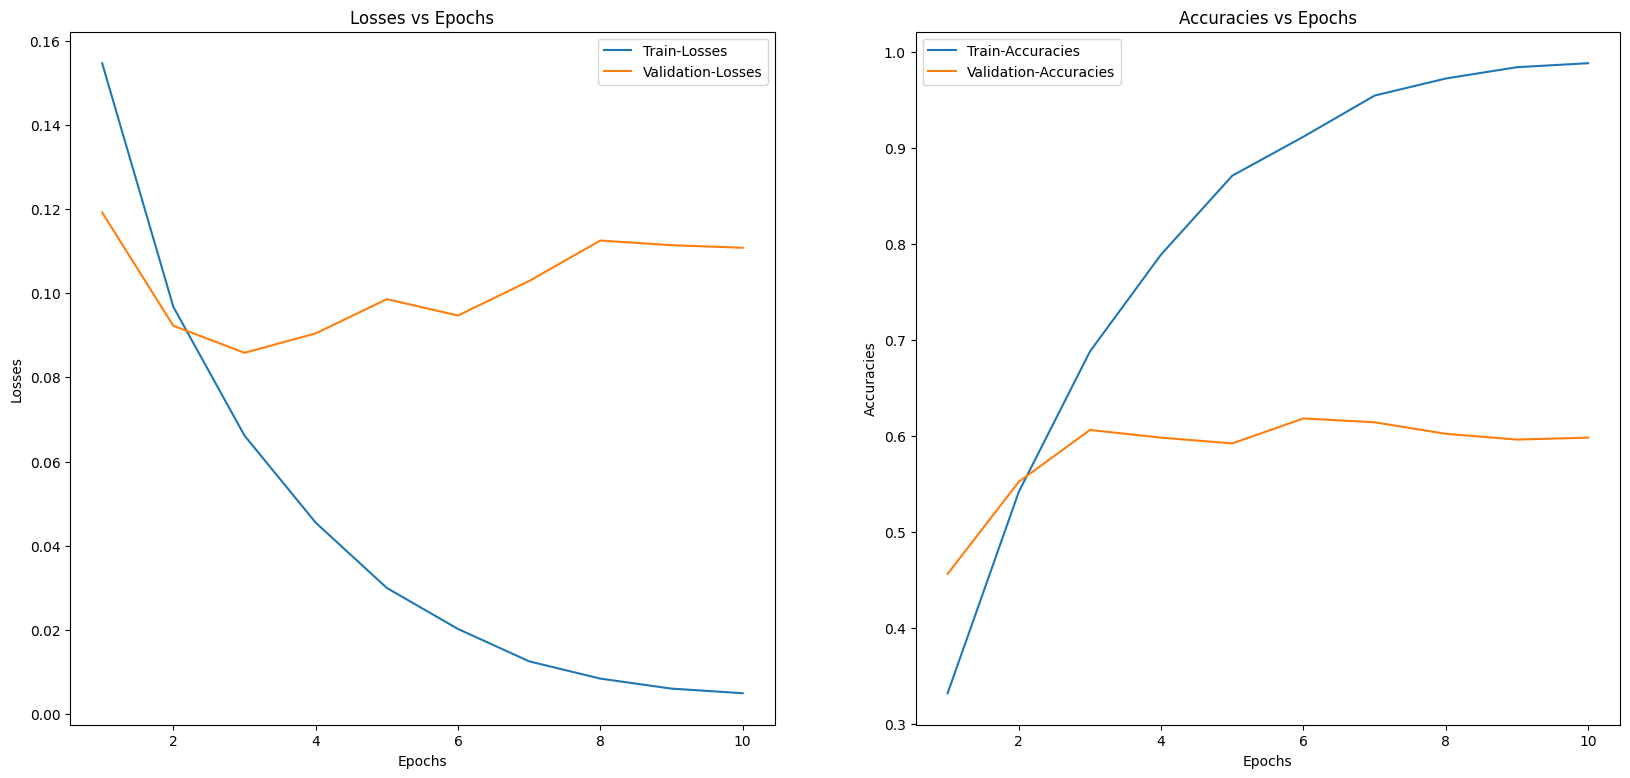

In [ ]:
plot(history, name="HistoryPlot1")

In [ ]:
# plot(history2, name="HistoryPlot2")